In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import numpy as np
import pandas as pd
from collections import defaultdict

# Load data
ratings = pd.read_csv("/content/drive/MyDrive/ml-100k/u.data", sep="\t",
                      names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("/content/drive/MyDrive/ml-100k/u.item", sep="|", encoding="latin-1",
                     names=["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
                            "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
                            "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
                            "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"])


In [27]:
ratings['reward'] = np.where(ratings['rating'] >= 4, 1, -1)

movies['genres'] = movies.iloc[:, 5:].apply(lambda x: '|'.join(x.index[x==1]), axis=1)
genre_columns = movies.columns[5:-1]

In [33]:
## 1. Multi-Armed Bandit Recommender

class EpsilonGreedyBandit:
    def __init__(self, epsilon=0.1):
        self.epsilon = epsilon
        self.movie_rewards = defaultdict(lambda: {'sum': 0, 'count': 0})
        self.movies = ratings['movie_id'].unique()

    def recommend(self, user_id=None):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.movies)
        else:
            if not self.movie_rewards:
                return np.random.choice(self.movies)
            avg_rewards = {mid: data['sum']/data['count']
                          for mid, data in self.movie_rewards.items() if data['count'] > 0}
            return max(avg_rewards.items(), key=lambda x: x[1])[0]

    def update(self, movie_id, reward):
        self.movie_rewards[movie_id]['sum'] += reward
        self.movie_rewards[movie_id]['count'] += 1

class UCBBandit:
    def __init__(self):
        self.movie_rewards = defaultdict(lambda: {'sum': 1, 'count': 1})
        self.movies = ratings['movie_id'].unique()
        self.total_counts = len(self.movies)

    def recommend(self, user_id=None):
        if not self.movie_rewards:
            return np.random.choice(self.movies)

        ucb_values = {}
        for mid in self.movies:
            if self.movie_rewards[mid]['count'] == 0:
                return mid

            avg_reward = self.movie_rewards[mid]['sum'] / self.movie_rewards[mid]['count']
            exploration_bonus = np.sqrt(2 * np.log(self.total_counts + 1) / (self.movie_rewards[mid]['count'] + 1e-5))
            ucb_values[mid] = avg_reward + exploration_bonus

        return max(ucb_values.items(), key=lambda x: x[1])[0]

    def update(self, movie_id, reward):
        self.movie_rewards[movie_id]['sum'] += reward
        self.movie_rewards[movie_id]['count'] += 1
        self.total_counts += 1

## 2. Q-Learning Recommender

class QLearningRecommender:
    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # learning rate
        self.gamma = gamma  # discount factor
        self.epsilon = epsilon  # exploration rate
        self.q_table = defaultdict(lambda: defaultdict(float))
        self.users = ratings['user_id'].unique()
        self.movies = ratings['movie_id'].unique()
        self.genres = genre_columns

    def get_state(self, user_id):
        user_ratings = ratings[ratings['user_id'] == user_id]
        if len(user_ratings) == 0:
            return 'new_user'

        user_movies = movies[movies['movie_id'].isin(user_ratings['movie_id'])]

        genre_counts = user_movies[genre_columns].sum()
        top_genres = genre_counts.nlargest(2).index.tolist()

        return '_'.join(top_genres) if len(top_genres) > 0 else 'new_user'

    def recommend(self, user_id):
        state = self.get_state(user_id)

        if np.random.random() < self.epsilon:
            return np.random.choice(self.movies)
        else:
            if state not in self.q_table or not self.q_table[state]:
                return np.random.choice(self.movies)
            return max(self.q_table[state].items(), key=lambda x: x[1])[0]

    def update(self, user_id, movie_id, reward, next_user_id=None):
        state = self.get_state(user_id)
        next_state = self.get_state(next_user_id) if next_user_id else state

        old_value = self.q_table[state][movie_id]
        next_max = max(self.q_table[next_state].values()) if self.q_table[next_state] else 0

        new_value = old_value + self.alpha * (reward + self.gamma * next_max - old_value)
        self.q_table[state][movie_id] = new_value




In [34]:
import matplotlib.pyplot as plt

def evaluate_rl_with_curves(recommender, n_iterations=5000):
    total_rewards = []
    exploration_rates = []

    cumulative_reward = 0
    sampled_users = ratings['user_id'].sample(n_iterations, replace=True).values

    for i in range(n_iterations):
        user_id = sampled_users[i]

        recommended_movie = recommender.recommend(user_id)

        user_movie = ratings[
            (ratings['user_id'] == user_id) &
            (ratings['movie_id'] == recommended_movie)
        ]
        if len(user_movie) > 0:
            reward = 1 if user_movie.iloc[0]['rating'] >= 4 else -1
        else:
            reward = 0

        if isinstance(recommender, QLearningRecommender):
            next_user_id = sampled_users[i+1] if i < n_iterations-1 else None
            recommender.update(user_id, recommended_movie, reward, next_user_id)
        else:
            recommender.update(recommended_movie, reward)

        cumulative_reward += reward
        total_rewards.append(cumulative_reward)

        if hasattr(recommender, 'epsilon'):
            exploration_rates.append(recommender.epsilon)
        else:
            exploration_rates.append(0)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(total_rewards)
    plt.title(f"Cumulative Reward: {recommender.__class__.__name__}")
    plt.xlabel("Iterations")
    plt.ylabel("Cumulative Reward")

    plt.subplot(1,2,2)
    plt.plot(exploration_rates)
    plt.title(f"Exploration Rate: {recommender.__class__.__name__}")
    plt.xlabel("Iterations")
    plt.ylabel("Exploration Rate")

    plt.tight_layout()
    plt.show()


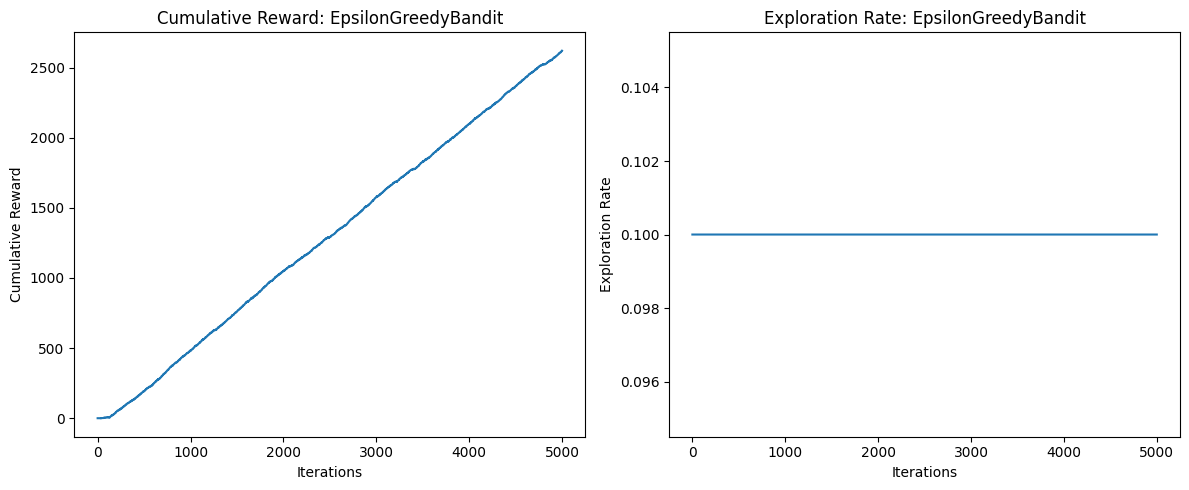

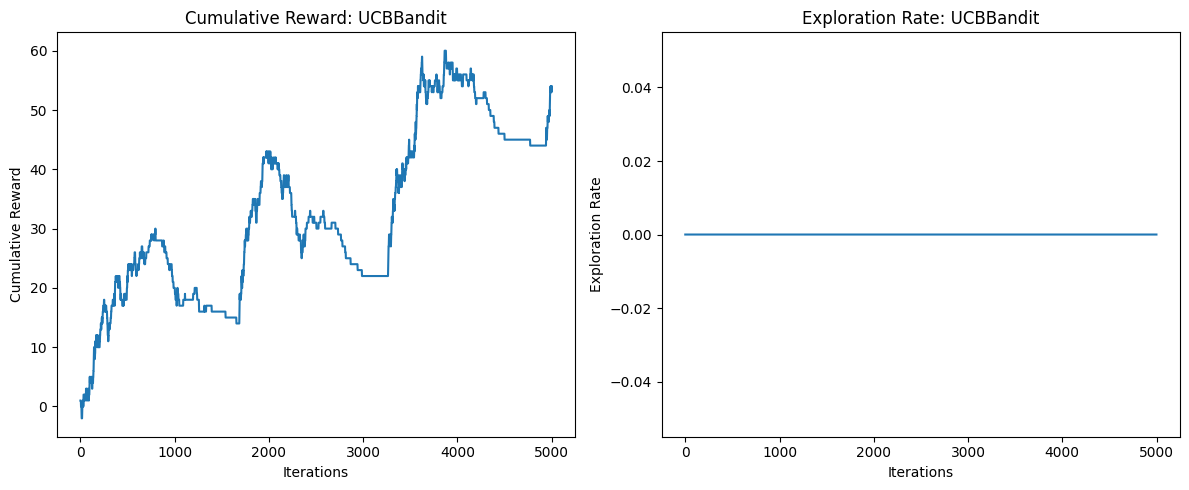

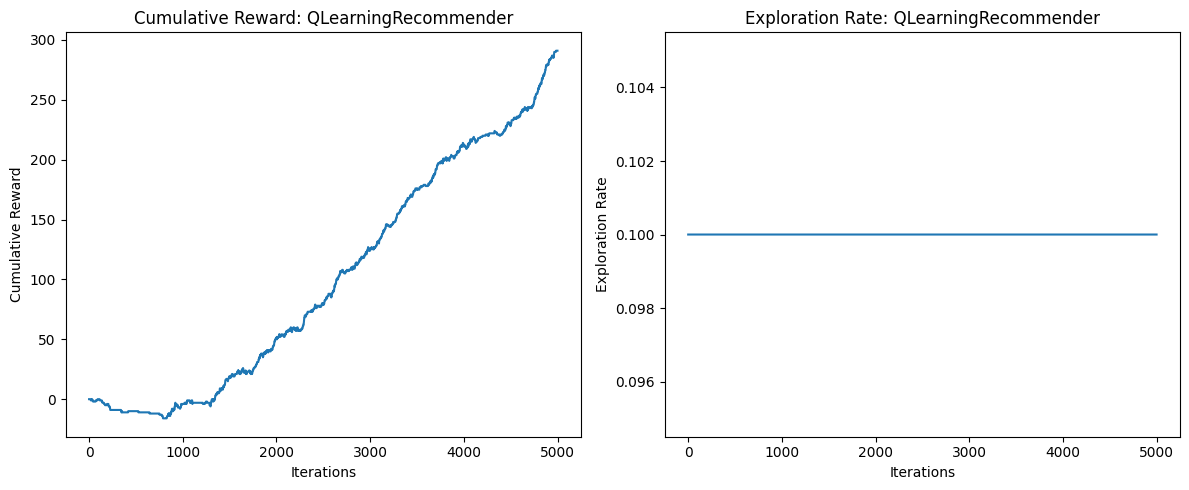

In [35]:
# Epsilon-Greedy Bandit
epsilon_bandit = EpsilonGreedyBandit(epsilon=0.1)
evaluate_rl_with_curves(epsilon_bandit, n_iterations=5000)

# UCB
ucb_bandit = UCBBandit()
evaluate_rl_with_curves(ucb_bandit, n_iterations=5000)

# Q-Learning
ql_recommender = QLearningRecommender(alpha=0.1, gamma=0.9, epsilon=0.1)
evaluate_rl_with_curves(ql_recommender, n_iterations=5000)


In [37]:
epsilon_bandit = EpsilonGreedyBandit(epsilon=0.1)

def recommend_movie(user_id):
    recommended_movie = epsilon_bandit.recommend(user_id)
    print(f"Recommended movie ID: {recommended_movie}")
    return recommended_movie

def user_feedback(movie_id):
    feedback = int(input("Did you like the movie? (1 = Yes, 0 = No): "))
    reward = 1 if feedback == 1 else -1
    epsilon_bandit.update(movie_id, reward)

# Example interaction
user_id = 123
movie_id = recommend_movie(user_id)
user_feedback(movie_id)


Recommended movie ID: 966
Did you like the movie? (1 = Yes, 0 = No): 0
